In [1]:
"""
multiclass_pipeline.py

Sequential pipeline:
Normalization -> Balancing (train only) -> GNN (Single) classifier

Evaluates for splits: 60/40, 70/30, 80/20
"""

import time
import psutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import random
import os
# ---------------------------
# Normalization & Balancing selectors
# ---------------------------
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import f1_score


In [2]:
# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [3]:
# ---------------------------
# User: load your DataFrame here
# Replace this with pd.read_csv(...) or pass your df
# ---------------------------
# Example: df = pd.read_csv("your_data.csv")

try:
    df = pd.read_csv("all_three.csv")
except NameError:
    raise RuntimeError("Please set `df` to your pandas DataFrame before running this script (e.g., df = pd.read_csv(...)).")


In [4]:
# ---------------------------
# Basic checks & feature selection
# ---------------------------
TARGET_COL = "label"
if TARGET_COL not in df.columns:
    raise RuntimeError(f"Target column '{TARGET_COL}' not found in DataFrame.")

drop_cols = []
for c in ["Unnamed: 0"]:
    if c in df.columns:
        drop_cols.append(c)

X_cols = [c for c in df.columns if c != TARGET_COL and c not in drop_cols]
X = df[X_cols].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.int64)

unique_labels = np.unique(y)
expected = set([0,1,2,3])
if not set(unique_labels).issubset(expected):
    print(f"Warning: labels found = {unique_labels}. Remapping to 0..3 if possible.")
    min_label = unique_labels.min()
    if set(unique_labels) == set(range(min_label, min_label + 4)):
        y = y - min_label
    else:
        raise RuntimeError("Labels are not in expected 0..3 range and can't auto-remap. Please fix labels.")

print("Feature shape:", X.shape, "Label counts:", pd.Series(y).value_counts().to_dict())


Feature shape: (427625, 23) Label counts: {0: 335847, 2: 55390, 3: 34134, 1: 2254}


In [5]:
# ---------------------------
# Normalization & Balancing selectors
# ---------------------------
# 🔹 Change ONLY these two strings to switch configuration
NORMALIZER = "Robust"       # "Decimal Point" / "Min-Max" / "Robust" / "Standard Scaler"
BALANCER   = "ADASYN"               # "SMOTE" / "SMOTE BORDERLINE" / "ADASYN" / "ADASYN + TOMEK LINKS"



In [6]:
# ---------------------------
# Decimal-scaling Normalizer
# ---------------------------
class DecimalScaler:
    def __init__(self):
        self.den = None

    def fit(self, X):
        max_abs = np.max(np.abs(X), axis=0)
        max_abs_safe = np.where(max_abs == 0, 1.0, max_abs)
        self.den = np.power(10.0, np.ceil(np.log10(max_abs_safe)))
        return self

    def transform(self, X):
        if self.den is None:
            raise RuntimeError("DecimalScaler not fitted.")
        return X / self.den

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


In [7]:
# ---------------------------
# Dataset wrapper and helpers
# ---------------------------

class TabularGNNDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, n_features)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [8]:
# ---------------------------
# Simple Batch GNN Layer
# ---------------------------
class SimpleBatchGNNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, X, A_norm):
        # X: (B, F)
        # A_norm: (B, B)
        agg = torch.matmul(A_norm, X)      # (B, F)
        out = self.linear(agg)             # (B, out_dim)
        return F.relu(out)

In [9]:
class PipelineModel(nn.Module):
    def __init__(self, input_dim, gnn_hidden=64, num_classes=4):
        super().__init__()
        self.gnn1 = SimpleBatchGNNLayer(in_dim=input_dim, out_dim=gnn_hidden)
        self.gnn2 = SimpleBatchGNNLayer(in_dim=gnn_hidden, out_dim=gnn_hidden)
        self.out = nn.Linear(gnn_hidden, num_classes)

    def forward(self, x, A_norm):
        g1 = self.gnn1(x, A_norm)
        g2 = self.gnn2(g1, A_norm)
        logits = self.out(g2)
        return logits


In [10]:
# ---------------------------
# Utility: build normalized adjacency via kNN (per-batch)
# ---------------------------
def build_knn_adj(features, k=5, self_loop=True):
    """
    features: numpy array (B, F)
    Return A_norm tensor (B, B) normalized adjacency (symmetric + row-normalized)
    """
    B = features.shape[0]
    k_eff = min(k, max(1, B-1))
    nbrs = NearestNeighbors(n_neighbors=k_eff + 1, algorithm='auto').fit(features)
    distances, indices = nbrs.kneighbors(features)
    A = np.zeros((B, B), dtype=np.float32)
    for i in range(B):
        neighs = indices[i]
        for j in neighs:
            if j == i and not self_loop:
                continue
            A[i, j] = 1.0
            A[j, i] = 1.0
    if self_loop:
        for i in range(B):
            A[i, i] = 1.0
    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    A_norm = A / row_sums
    return torch.tensor(A_norm, dtype=torch.float32)


In [11]:
# ---------------------------
# Training & Evaluation functions
# ---------------------------
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)    # (B, n_features)
        y_batch = y_batch.to(device)

        with torch.no_grad():
            flat = X_batch.cpu().numpy()  # (B, n_features)
        A_norm = build_knn_adj(flat).to(device)

        optimizer.zero_grad()
        logits = model(X_batch, A_norm)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    ys = []
    probs = []
    preds = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        flat = X_batch.cpu().numpy()  # (B, n_features)
        A_norm = build_knn_adj(flat).to(device)

        logits = model(X_batch, A_norm)
        prob = F.softmax(logits, dim=1).cpu().numpy()
        pred = logits.argmax(dim=1).cpu().numpy()
        ys.append(y_batch.cpu().numpy())
        probs.append(prob)
        preds.append(pred)
    y_true = np.concatenate(ys, axis=0)
    y_probs = np.vstack(probs)
    y_pred = np.concatenate(preds, axis=0)
    return y_true, y_pred, y_probs


In [12]:
# ---------------------------
# Main training/eval loop for given split
# ---------------------------
def run_for_split(X_all, y_all, train_size, seed=SEED, device=None):
    """
    train_size float in (0,1) -> e.g., 0.6, 0.7, 0.8
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, train_size=train_size,
        stratify=y_all, random_state=seed
    )

    # ---------------------------
    # Normalization (train only)
    # ---------------------------
    if NORMALIZER == "Decimal Point":
        scaler = DecimalScaler()
    elif NORMALIZER == "Min-Max":
        scaler = MinMaxScaler()
    elif NORMALIZER == "Robust":
        scaler = RobustScaler()
    elif NORMALIZER == "Standard Scaler":
        scaler = StandardScaler()
    else:
        raise ValueError(f"Unknown NORMALIZER: {NORMALIZER}")

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ---------------------------
    # Balancing (train only)
    # ---------------------------
    if BALANCER == "SMOTE":
        sm = SMOTE(random_state=seed)
        X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

    elif BALANCER == "SMOTE BORDERLINE":
        sm = BorderlineSMOTE(random_state=seed)
        X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

    elif BALANCER == "ADASYN":
        sm = ADASYN(random_state=seed)
        X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

    elif BALANCER == "ADASYN + TOMEK LINKS":
        ada = ADASYN(random_state=seed)
        X_tmp, y_tmp = ada.fit_resample(X_train_scaled, y_train)
        tl = TomekLinks()
        X_res, y_res = tl.fit_resample(X_tmp, y_tmp)

    else:
        raise ValueError(f"Unknown BALANCER: {BALANCER}")

    print(f"After {BALANCER}: class counts: {pd.Series(y_res).value_counts().to_dict()}")

    # Create datasets and loaders for GNN (tabular features)
    train_ds = TabularGNNDataset(X_res, y_res)
    test_ds = TabularGNNDataset(X_test_scaled, y_test)
    BATCH_SIZE = 128
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    # Build GNN model
    input_dim = X_res.shape[1]
    model = PipelineModel(input_dim=input_dim, gnn_hidden=64, num_classes=4).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    EPOCHS = 10  # change as required

    start_time = time.time()
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        y_true_tmp, y_pred_tmp, y_probs_tmp = evaluate_model(model, test_loader, device)
        acc_tmp = accuracy_score(y_true_tmp, y_pred_tmp)
        print(f"Epoch {epoch}/{EPOCHS} - train_loss: {train_loss:.4f}, test_acc: {acc_tmp:.4f}")
    runtime = time.time() - start_time

    # Final evaluation
    y_true, y_pred, y_probs = evaluate_model(model, test_loader, device)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

    # F1 scores
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # ROC AUC
    try:
        auc_score = roc_auc_score(y_true, y_probs, multi_class='ovr')
    except Exception:
        try:
            n_classes = y_probs.shape[1]
            aucs = []
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
                aucs.append(auc(fpr, tpr))
            auc_score = np.mean(aucs)
        except Exception:
            auc_score = float('nan')

    cm = confusion_matrix(y_true, y_pred)

    mem_info = psutil.Process(os.getpid()).memory_info()
    ram_used_mb = mem_info.rss / (1024 ** 2)

    results = {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_weighted),
        "roc_auc": float(auc_score) if not np.isnan(auc_score) else auc_score,
        "confusion_matrix": cm.tolist(),
        "runtime_sec": float(runtime),
        "ram_used_mb": float(ram_used_mb),
        "y_true": y_true,
        "y_probs": y_probs,
    }

    # ----- FULL PRINT, NO TRUNCATION OF METRICS -----
    print("\n===== FULL EVALUATION RESULTS =====")
    for k, v in results.items():
        if k in ["y_true", "y_probs"]:
            arr = np.array(v)
            print(f"{k}: array with shape {arr.shape}")
        elif k == "confusion_matrix":
            print(f"{k}:")
            print(np.array(v))
        else:
            print(f"{k}: {v}")
    print("====================================\n")

    # Full classification report
    print("\n===== FULL CLASSIFICATION REPORT =====\n")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Confusion Matrix Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix (train_size={train_size:.2f})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC Curves
    try:
        if y_probs.ndim > 1 and y_probs.shape[1] > 1:
            n_classes = y_probs.shape[1]
            plt.figure(figsize=(7, 6))
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
                roc_auc_val = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc_val:.2f})")
            plt.plot([0, 1], [0, 1], 'k--')
            plt.title(f"ROC Curve (Multiclass) - train_size={train_size:.2f}")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend(loc="lower right")
            plt.show()
        else:
            if len(np.unique(y_true)) == 2:
                fpr, tpr, _ = roc_curve(y_true, y_probs)
                roc_auc_val = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"AUC={roc_auc_val:.2f}")
                plt.plot([0, 1], [0, 1], 'k--')
                plt.title("ROC Curve (Binary)")
                plt.xlabel("False Positive Rate")
                plt.ylabel("True Positive Rate")
                plt.legend(loc="lower right")
                plt.show()
            else:
                print("⚠ ROC curve skipped: multiclass detected but only 1D probs available.")
    except Exception as e:
        print(f"⚠ ROC plotting failed: {e}")

    return results


cpu


 Running GNN pipeline with train_size = 0.60 (train/test = 60%/40%)

After ADASYN: class counts: {3: 202718, 0: 201508, 2: 201506, 1: 201493}
Epoch 1/10 - train_loss: 1.1612, test_acc: 0.8602
Epoch 2/10 - train_loss: 0.9294, test_acc: 0.8800
Epoch 3/10 - train_loss: 0.7915, test_acc: 0.8803
Epoch 4/10 - train_loss: 0.7130, test_acc: 0.8929
Epoch 5/10 - train_loss: 0.6875, test_acc: 0.9069
Epoch 6/10 - train_loss: 0.6858, test_acc: 0.9006
Epoch 7/10 - train_loss: 0.6628, test_acc: 0.9024
Epoch 8/10 - train_loss: 0.6558, test_acc: 0.9114
Epoch 9/10 - train_loss: 0.6391, test_acc: 0.9134
Epoch 10/10 - train_loss: 0.6364, test_acc: 0.9157

===== FULL EVALUATION RESULTS =====
accuracy: 0.9156796258403975
precision: 0.6893654202545891
recall: 0.6129462317360247
f1_macro: 0.6402722908924581
f1_weighted: 0.9082582609166737
roc_auc: 0.9364295879744616
confusion_matrix:
[[130005    191    850   3293]
 [   546    122     16    217]
 [  1034     10  21071     41]
 [  7916    132    177   542

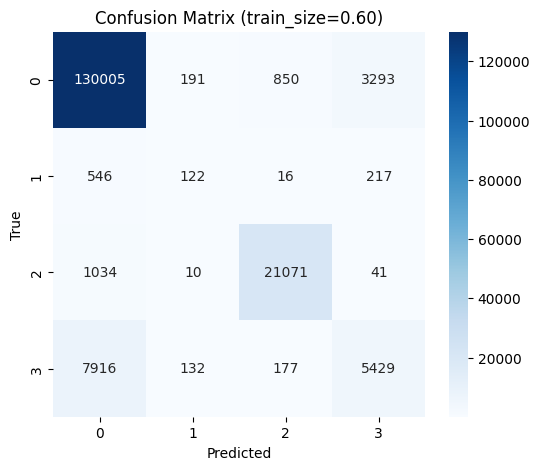

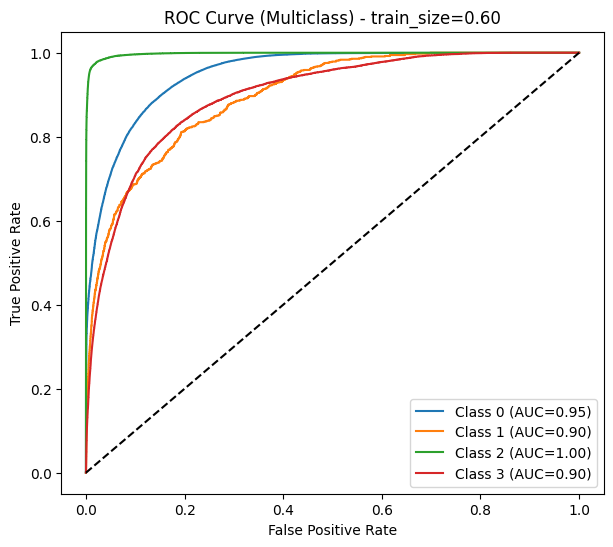


All done. Results keys: ['train_60']


In [13]:
# ---------------------------
# Run for the three splits
# ---------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    splits = [0.6]
    all_results = {}
    for s in splits:
        print("\n\n==============================")
        print(f" Running GNN pipeline with train_size = {s:.2f} (train/test = {s:.0%}/{(1-s):.0%})")
        print("==============================\n")
        res = run_for_split(X, y, train_size=s, seed=SEED, device=device)
        all_results[f"train_{int(s*100)}"] = res

    print("\nAll done. Results keys:", list(all_results.keys()))


cpu


 Running GNN pipeline with train_size = 0.70 (train/test = 70%/30%)

After ADASYN: class counts: {3: 235344, 2: 235104, 0: 235092, 1: 234954}
Epoch 1/10 - train_loss: 1.2584, test_acc: 0.8641
Epoch 2/10 - train_loss: 0.7812, test_acc: 0.8920
Epoch 3/10 - train_loss: 0.7082, test_acc: 0.8895
Epoch 4/10 - train_loss: 0.6826, test_acc: 0.9051
Epoch 5/10 - train_loss: 0.6690, test_acc: 0.9096
Epoch 6/10 - train_loss: 0.6610, test_acc: 0.9090
Epoch 7/10 - train_loss: 0.6394, test_acc: 0.9085
Epoch 8/10 - train_loss: 0.6359, test_acc: 0.9103
Epoch 9/10 - train_loss: 0.6247, test_acc: 0.9143
Epoch 10/10 - train_loss: 0.6123, test_acc: 0.9185

===== FULL EVALUATION RESULTS =====
accuracy: 0.918527064105762
precision: 0.6997289401941434
recall: 0.600696610213127
f1_macro: 0.6309889550234737
f1_weighted: 0.9091536411575725
roc_auc: 0.9368456675124657
confusion_matrix:
[[98046   101   589  2019]
 [  453    68    12   143]
 [  635    29 15927    26]
 [ 6261    46   138  3795]]
runtime_sec: 1

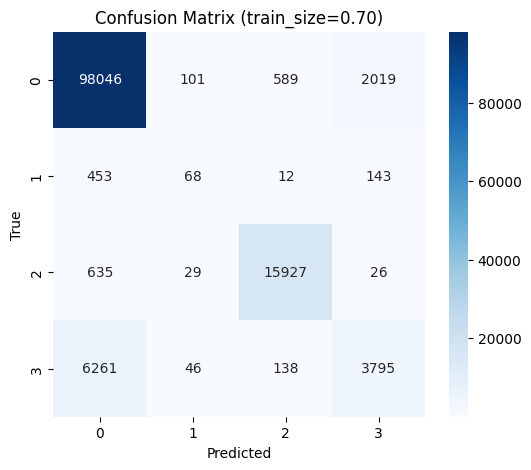

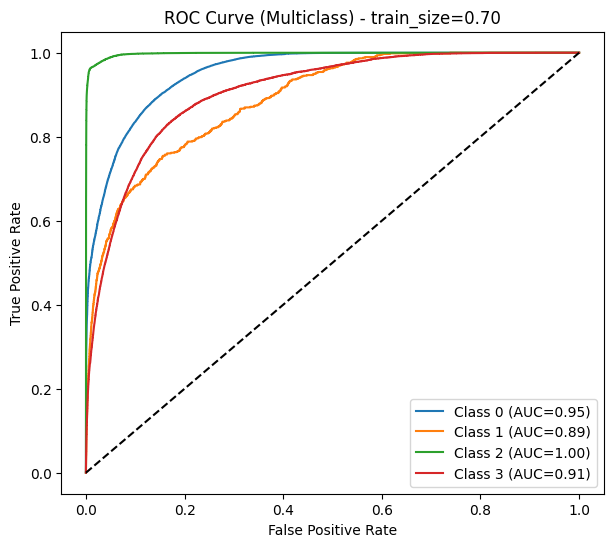


All done. Results keys: ['train_70']


In [14]:
# ---------------------------
# Run for the three splits
# ---------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    splits = [0.7]
    all_results = {}
    for s in splits:
        print("\n\n==============================")
        print(f" Running GNN pipeline with train_size = {s:.2f} (train/test = {s:.0%}/{(1-s):.0%})")
        print("==============================\n")
        res = run_for_split(X, y, train_size=s, seed=SEED, device=device)
        all_results[f"train_{int(s*100)}"] = res

    print("\nAll done. Results keys:", list(all_results.keys()))


cpu


 Running GNN pipeline with train_size = 0.80 (train/test = 80%/20%)

After ADASYN: class counts: {2: 268681, 0: 268678, 1: 268563, 3: 267117}
Epoch 1/10 - train_loss: 0.9215, test_acc: 0.8720
Epoch 2/10 - train_loss: 0.7592, test_acc: 0.8911
Epoch 3/10 - train_loss: 0.7001, test_acc: 0.9095
Epoch 4/10 - train_loss: 0.6815, test_acc: 0.9102
Epoch 5/10 - train_loss: 0.6660, test_acc: 0.9075
Epoch 6/10 - train_loss: 0.6480, test_acc: 0.9137
Epoch 7/10 - train_loss: 0.6346, test_acc: 0.9146
Epoch 8/10 - train_loss: 0.6219, test_acc: 0.9142
Epoch 9/10 - train_loss: 0.6287, test_acc: 0.9122
Epoch 10/10 - train_loss: 0.6213, test_acc: 0.9101

===== FULL EVALUATION RESULTS =====
accuracy: 0.9100613855597779
precision: 0.6525055756944537
recall: 0.5938692397320174
f1_macro: 0.6129813746791111
f1_weighted: 0.9026434386559257
roc_auc: 0.931845205903058
confusion_matrix:
[[64550   100   448  2071]
 [  265    34     5   147]
 [  341    10 10703    24]
 [ 4160    30    91  2546]]
runtime_sec: 

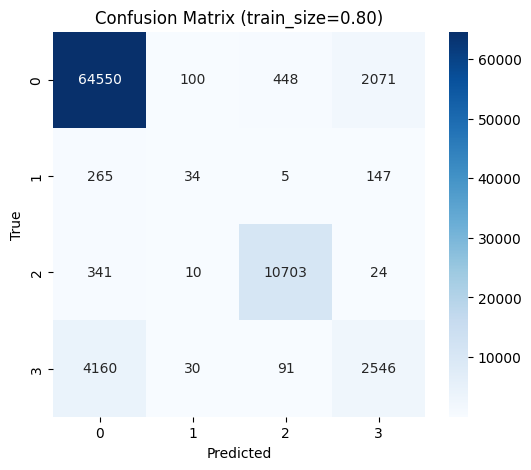

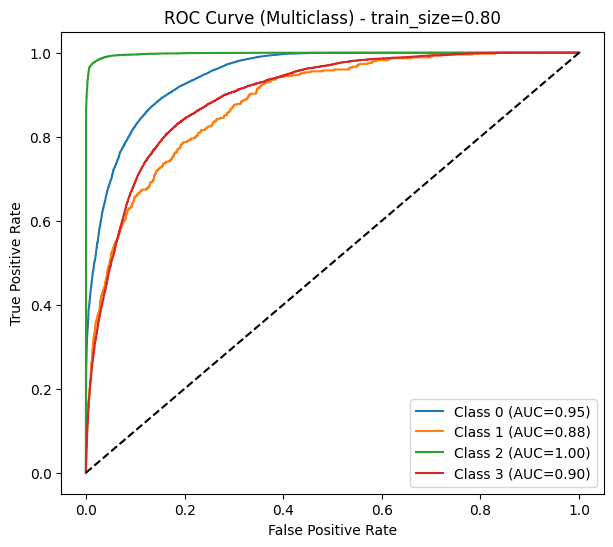


All done. Results keys: ['train_80']


In [15]:
# ---------------------------
# Run for the three splits
# ---------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    splits = [0.8]
    all_results = {}
    for s in splits:
        print("\n\n==============================")
        print(f" Running GNN pipeline with train_size = {s:.2f} (train/test = {s:.0%}/{(1-s):.0%})")
        print("==============================\n")
        res = run_for_split(X, y, train_size=s, seed=SEED, device=device)
        all_results[f"train_{int(s*100)}"] = res

    print("\nAll done. Results keys:", list(all_results.keys()))
